# Estimate \(d\) and \(\sigma\) from a simulated Logit Graph

Minimal end-to-end example using **[logit-graph 0.1.3+](https://pypi.org/project/logit-graph/)** from PyPI:

1. Install the published package.
2. Simulate a graph with **known** \(n=200\), \(d\), and \(\sigma\).
3. Recover \(\hat d\) via **AIC** (`select_d_ensemble`).
4. Recover \(\hat\sigma\) via the **Layer-2 offset logit** at \(\hat d\) (`estimate_sigma_from_graph`).

No repo checkout is required. The next cell installs `logit-graph>=0.1.3` from PyPI (uses `uv pip` when available, otherwise bootstraps `pip` via `ensurepip`).

## 1. Install from PyPI

In [1]:
import importlib.util
import shutil
import subprocess
import sys

PKG = "logit-graph>=0.1.3"
PKG_NAME = "logit_graph"


def _run(cmd: list[str]) -> None:
    print("$", " ".join(cmd))
    subprocess.check_call(cmd)


def _has_pip() -> bool:
    return importlib.util.find_spec("pip") is not None


def _ensure_pip() -> None:
    if _has_pip():
        return
    print("pip not found in this kernel — bootstrapping with ensurepip …")
    _run([sys.executable, "-m", "ensurepip", "--upgrade"])


def _install_with_pip() -> None:
    _ensure_pip()
    _run([sys.executable, "-m", "pip", "install", "-q", PKG])


def _install_with_uv() -> None:
    _run(["uv", "pip", "install", "-q", PKG, "--python", sys.executable])


if importlib.util.find_spec(PKG_NAME) is not None:
    print(f"{PKG_NAME} already importable in {sys.executable}")
    print("Skipping install (fine for local editable dev installs).")
elif shutil.which("uv") is not None:
    try:
        _install_with_uv()
    except subprocess.CalledProcessError:
        print("uv install failed; falling back to pip …")
        _install_with_pip()
else:
    _install_with_pip()

print("Done. If you just installed the package, restart the kernel once.")

logit_graph already importable in /Users/maruanottoni/home/master/research/all_logit/logit-graph/.venv/bin/python
Skipping install (fine for local editable dev installs).
Done. If you just installed the package, restart the kernel once.


## 2. Simulate a graph with known parameters

We fix the ground truth and generate one LG sample:

| parameter | value |
|---|---:|
| \(n\) | 200 |
| \(d\) | 1 |
| \(\sigma\) | \(-4.0\) |
| target density | 0.10 |

For \(d \ge 1\) the sampler runs Layer-2 Gibbs (`feature_mode="incremental"`, `β=1`).

In [2]:
import os
for v in ("OPENBLAS_NUM_THREADS", "OMP_NUM_THREADS", "MKL_NUM_THREADS"):
    os.environ.setdefault(v, "1")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

from logit_graph import (
    calculate_graph_attributes,
    estimate_sigma_from_graph,
    recommended_iterations,
    select_d_ensemble,
    simulate_graph,
)

SEED = 42
np.random.seed(SEED)

N = 200
D_TRUE = 1
SIGMA_TRUE = -4.0
TARGET_DENSITY = 0.10
D_CANDIDATES = [0, 1, 2, 3]
FEATURE_MODE = "incremental"

N_ITER = min(recommended_iterations(N), 30_000)

adj, meta = simulate_graph(
    N,
    D_TRUE,
    sigma=SIGMA_TRUE,
    n_iter=N_ITER,
    feature_mode=FEATURE_MODE,
    target_density=TARGET_DENSITY,
    seed=SEED,
    return_meta=True,
)

G = nx.from_numpy_array(adj)
print(f"Ground truth:  n={N}  d={D_TRUE}  σ={SIGMA_TRUE:+.4f}")
print(f"Simulated:     |E|={G.number_of_edges()}  density={meta['density']:.4f}  β={meta['beta']:.2f}  Gibbs iters={int(meta['n_iter_used'])}")
print(calculate_graph_attributes(G))

Ground truth:  n=200  d=1  σ=-4.0000
Simulated:     |E|=425  density=0.0214  β=1.00  Gibbs iters=30000
{'nodes': 200, 'edges': 425, 'density': 0.02135678391959799, 'avg_clustering': 0.04547619047619045, 'assortativity': 0.03306809101903422, 'num_components': 8, 'largest_component_size': 193, 'avg_path_length': 3.7665155440414506, 'diameter': 8}


## 3. Visualize the simulated graph

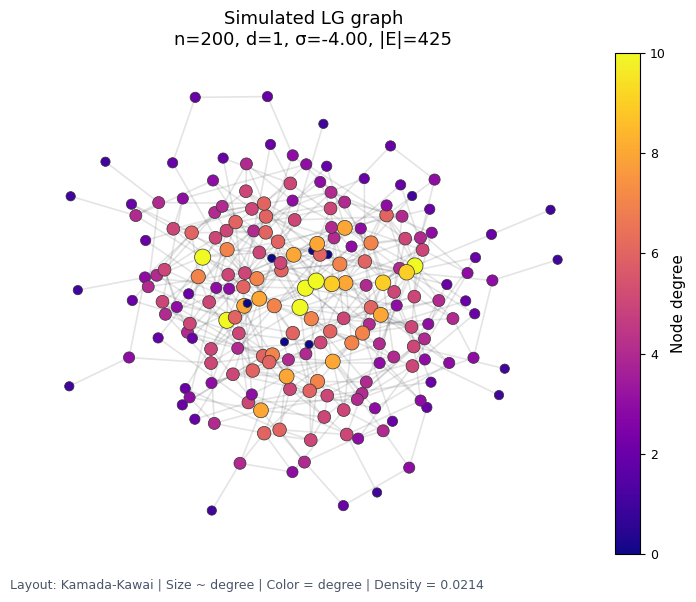

In [3]:
fig, ax = plt.subplots(figsize=(7, 6))
# More visually stable layout (kamada_kawai) and reproducibility
pos = nx.kamada_kawai_layout(G, scale=1.0)
deg = np.array([d for _, d in G.degree()])

# Draw edges under nodes, with a subtle shadow
nx.draw_networkx_edges(
    G, pos, ax=ax, alpha=0.12, width=1.2, edge_color="#23272e"
)

# Draw nodes: more contrast, larger default, clearer color scale
nc = nx.draw_networkx_nodes(
    G,
    pos,
    ax=ax,
    node_size=35 + 10 * deg,
    node_color=deg,
    cmap="plasma",
    linewidths=0.5,
    edgecolors="#333",
)

# Add colorbar for degree
sm = plt.cm.ScalarMappable(
    cmap="plasma", norm=plt.Normalize(vmin=deg.min(), vmax=deg.max())
)
cbar = plt.colorbar(sm, ax=ax, fraction=0.044, pad=0.01)
cbar.set_label("Node degree", fontsize=11)
cbar.ax.tick_params(labelsize=9)

ax.set_title(
    f"Simulated LG graph\nn={N}, d={D_TRUE}, σ={SIGMA_TRUE:+.2f}, |E|={G.number_of_edges()}",
    fontsize=13
)
ax.set_axis_off()
# Extra info in a caption below the plot
fig.text(
    0.01, 0.01,
    f"Layout: Kamada-Kawai | Size ~ degree | Color = degree | Density = {meta['density']:.4f}",
    fontsize=9, color="#4A5568"
)
fig.tight_layout(rect=[0, 0.03, 1, 1])
plt.show()

## 4. Estimate \(\hat d\) via AIC

`select_d_ensemble` fits the Layer-2 offset logit at each candidate \(d \in \{0,1,2,3\}\) and picks the AIC minimizer.

In [4]:
d_hat, aic_stats = select_d_ensemble(
    graphs=[adj],
    d_candidates=D_CANDIDATES,
    feature_mode=FEATURE_MODE,
    extra_penalty_per_d=0.0,
)

aic_rows = []
for d, s in aic_stats.items():
    aic_rows.append({
        "d": d,
        "AIC": s["aic"],
        "ll": s["ll"],
        "σ̂(d)": s["sigma_hat"],
        "n_obs": int(s["n_obs"]),
        "selected": "✓" if d == d_hat else "",
    })
aic_table = pd.DataFrame(aic_rows).set_index("d")

print(f"AIC-selected  d̂ = {d_hat}   (true d = {D_TRUE})")
aic_table.round(3)

AIC-selected  d̂ = 1   (true d = 1)


,AIC,ll,σ̂(d),n_obs,selected
d,,,,,
0,4112.286,-2055.143,-3.825,19900,
1,4048.172,-2023.086,-3.972,19900,✓
2,4189.842,-2093.921,-5.078,19900,
3,4239.885,-2118.942,-7.160,19900,


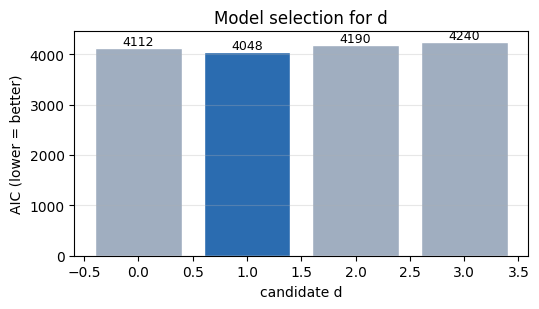

In [5]:
fig, ax = plt.subplots(figsize=(5.5, 3.2))
xs = list(aic_table.index)
ys = aic_table["AIC"].values
colors = ["#2b6cb0" if d == d_hat else "#a0aec0" for d in xs]
ax.bar(xs, ys, color=colors, edgecolor="white")
for x, y in zip(xs, ys):
    ax.text(x, y, f"{y:.0f}", ha="center", va="bottom", fontsize=9)
ax.set_xlabel("candidate d")
ax.set_ylabel("AIC (lower = better)")
ax.set_title("Model selection for d")
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
plt.show()

## 5. Estimate \(\hat\sigma\) at \(\hat d\)

At the AIC-selected dimension, `estimate_sigma_from_graph` returns the offset-logit intercept — the same \(\sigma\) reported in the AIC table.

In [6]:
sigma_hat = estimate_sigma_from_graph(adj, d_hat, feature_mode=FEATURE_MODE)
sigma_at_true_d = estimate_sigma_from_graph(adj, D_TRUE, feature_mode=FEATURE_MODE)

summary = pd.DataFrame([
    {"parameter": "d", "true": D_TRUE, "estimated": d_hat, "|error|": abs(d_hat - D_TRUE)},
    {"parameter": "σ @ d̂", "true": SIGMA_TRUE, "estimated": sigma_hat, "|error|": abs(sigma_hat - SIGMA_TRUE)},
    {"parameter": f"σ @ true d={D_TRUE}", "true": SIGMA_TRUE, "estimated": sigma_at_true_d, "|error|": abs(sigma_at_true_d - SIGMA_TRUE)},
]).set_index("parameter")

print(f"σ̂ at d̂={d_hat}: {sigma_hat:+.4f}   (true σ = {SIGMA_TRUE:+.4f},  |Δ| = {abs(sigma_hat - SIGMA_TRUE):.4f})")
summary.round(4)

σ̂ at d̂=1: -3.9719   (true σ = -4.0000,  |Δ| = 0.0281)


,true,estimated,|error|
parameter,,,
d,1.0,1.0000,0.0000
σ @ d̂,-4.0,-3.9719,0.0281
σ @ true d=1,-4.0,-3.9719,0.0281


## 6. Recovery summary

On this single draw with \(n=200\), \(d=1\), \(\sigma=-4\):

- **\(\hat d\)** should match the true \(d\) when AIC selects the correct model order.
- **\(\hat\sigma\)** is the offset-logit intercept at \(\hat d\); it is usually close to the true \(\sigma\) when \(\hat d = d\).

Try changing `D_TRUE`, `SIGMA_TRUE`, or `SEED` in cell 2 to explore other regimes.